#### 2026.03.09 수업 때 말씀해주심

# Seq2Seq 모델 Q&A Chatbot 구현

1. QnA 데이터셋을 찾아서 처리해서 준비한다. (전처리 전반)
2. Encoder, Decoder를 만들고 이것으로 Seq2Seq(Encoder+Decoder) 모델을 만든다.
3. 1에서 준비한 데이터로 2에서 만든 모델을 학습시킨다. 
4. Chatbot을 만든다.(모델 추론+ while문 사용하기)


**✅추가 말씀**
- 입력 데이터를 집어넣고 단편적으로 추론하는 것이 끝이었음
- input 이용해서 입력을 받고 -> 입력을 encoder을 통과해서 decoder을 통과하게 해서 추론하게 한다면 output이 나올 것임
- -> output에서 나온 것을 사용자가 사용하도록 하기 

**예시**
ex. 
- 챗봇 <- "좋은 아침이야." (input)
-   "네, 좋은 아침입니다." (output)
-   이에 대한 적절한 대답을 하게 만들기
-    = 기본적인 input&output이 나오게 하는 구조 만들기

---

## PDA -> CSV 파일로 변화

**참고**
- [[ASPOSE](https://kb.aspose.com/ko/pdf/python/how-to-convert-pdf-to-csv-in-python/)]: PDA 파일 로드 참고
- [[ExcelSaveOptions](https://reference.aspose.com/pdf/python-net/aspose.pdf/excelsaveoptions/)]
- [[APOSE.PDA](https://kb.aspose.com/ko/pdf/python/extract-data-from-pdf-form-using-python/)]: python을 사용하여 PDF 양식 필드에서 데이터 추출 방법 참고

**출처**
- [[화장품 QnA](https://mfds.go.kr/brd/m_1060/view.do?seq=15772&srchFr=&srchTo=&srchWord=%EC%9E%90%EC%A3%BC%ED%95%98%EB%8A%94+%EC%A7%88%EB%AC%B8%EC%A7%91&srchTp=0&itm_seq_1=0&itm_seq_2=0&multi_itm_seq=0&company_cd=&company_nm=&Data_stts_gubun=C9999&page=1)]

1. 정의:[화장품 해당 여부]( 25페이지~32페이지)
	 [화장품의 유형](33페이지~35페이지)
2. 화장품의 제조, 유통:[영업의 등록] 영업의 등록(39페이지~48페이지)
				[화장품 제조업의 등록 등] (49페이지~51페이지)
						[화장품제조업 등의 변경 등록] (52페이지~55)
				[화장품책임판매업 등의 변경등록] (56페이지~59)
 				[책임판매관리자의 자격기준 등] (60페이지~70)
 				[책임판매관리자 등의 교육] (71페이지~73)
 				[책임판매관리자 등의 교육] (71페이지~73)

---

### aspose

In [1]:
import pandas as pd
#datasets 이름에서 딴 df
# df=pd.read_csv('~~~')

In [2]:
!pip install aspose-pdf

   ---------------------------------------- 0.0/89.5 MB ? eta -:--:--
   - -------------------------------------- 2.4/89.5 MB 12.2 MB/s eta 0:00:08
   -- ------------------------------------- 4.7/89.5 MB 11.4 MB/s eta 0:00:08
   --- ------------------------------------ 7.1/89.5 MB 11.5 MB/s eta 0:00:08
   ---- ----------------------------------- 9.4/89.5 MB 11.5 MB/s eta 0:00:07
   ----- ---------------------------------- 11.8/89.5 MB 11.2 MB/s eta 0:00:07
   ----- ---------------------------------- 12.8/89.5 MB 10.1 MB/s eta 0:00:08
   ------ --------------------------------- 13.6/89.5 MB 10.2 MB/s eta 0:00:08
   ------ --------------------------------- 15.5/89.5 MB 9.2 MB/s eta 0:00:09
   ------- -------------------------------- 17.8/89.5 MB 9.4 MB/s eta 0:00:08
   --------- ------------------------------ 20.2/89.5 MB 9.6 MB/s eta 0:00:08
   ---------- ----------------------------- 22.5/89.5 MB 9.8 MB/s eta 0:00:07
   ----------- ---------------------------- 25.2/89.5 MB 9.9 MB/s eta

In [7]:
import aspose.pdf as pdf

makeup_pdf=pdf.Document('C:\\SKN_24\\과제\\nlp_practice\\data\\2025+자주하는+질문집(화장품).pdf')

In [9]:
# TableAbsorber 객체 생성(테이블 읽는 도구임)
table_absorber=pdf.text.TableAbsorber

In [10]:
table_absorber.visit(makeup_pdf.pages[1])
# 버전 호환성 문제 발생
# aspose.pdf(유로 라이브러리) 

TypeError: descriptor 'visit' for 'aspose.pdf.text.TableAbsorber' objects doesn't apply to a 'aspose.pdf.Page' object

---

### pdfplumber

In [11]:
!pip install pdfplumber

  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
   ---------------------------------------- 0.0/6.6 MB ? eta -:--:--
   -------------- ------------------------- 2.4/6.6 MB 11.2 MB/s eta 0:00:01
   ---------------------------- ----------- 4.7/6.6 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 6.6/6.6 MB 10.7 MB/s  0:00:00
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   --------------------------- ------------ 2.4/3.5 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 10.8 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ------------------------- -------------- 2.4/3.7 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 10.5 MB/s  0:00:00
Using cached pycparser-3.0-py3-none-any.whl (48 kB)

   ---------------------------------------- 0/6 [pypdfium2]
   ---------------------------------------- 0/6 [pypdfium2]
   -----------------------

In [12]:
import pdfplumber
import pandas as pd

In [20]:
#데이터 로드
with pdfplumber.open('C:\\SKN_24\\과제\\nlp_practice\\data\\2025+자주하는+질문집(화장품).pdf') as pdf:
    all_tables=[]   #모든 테이블=모든 페이지 담는 빈 리스트 생성(배열 생성)
    
    #모든 페이지 순회
    for page_num, page in enumerate(pdf.pages):
        print(f"페이지 {page_num+1}")

        tables=page.extract_tables() 

        #데이터프레임 생성
        for table in tables:
            for row in table:
                #cleaned_row=[cell.strip() if isinstance(cell, str) else cell in row]
                cleaned_row=[cell.strip() if isinstance(cell, str) else cell  for cell in row]

                if any(cell for cell in cleaned_row if cell):
                    all_tables.append(cleaned_row)


페이지 1
페이지 2
페이지 3
페이지 4
페이지 5
페이지 6
페이지 7
페이지 8
페이지 9
페이지 10
페이지 11
페이지 12
페이지 13
페이지 14
페이지 15
페이지 16
페이지 17
페이지 18
페이지 19
페이지 20
페이지 21
페이지 22
페이지 23
페이지 24
페이지 25
페이지 26
페이지 27
페이지 28
페이지 29
페이지 30
페이지 31
페이지 32
페이지 33
페이지 34
페이지 35
페이지 36
페이지 37
페이지 38
페이지 39
페이지 40
페이지 41
페이지 42
페이지 43
페이지 44
페이지 45
페이지 46
페이지 47
페이지 48
페이지 49
페이지 50
페이지 51
페이지 52
페이지 53
페이지 54
페이지 55
페이지 56
페이지 57
페이지 58
페이지 59
페이지 60
페이지 61
페이지 62
페이지 63
페이지 64
페이지 65
페이지 66
페이지 67
페이지 68
페이지 69
페이지 70
페이지 71
페이지 72
페이지 73
페이지 74
페이지 75
페이지 76
페이지 77
페이지 78
페이지 79
페이지 80
페이지 81
페이지 82
페이지 83
페이지 84
페이지 85
페이지 86
페이지 87
페이지 88
페이지 89
페이지 90
페이지 91
페이지 92
페이지 93
페이지 94
페이지 95
페이지 96
페이지 97
페이지 98
페이지 99
페이지 100
페이지 101
페이지 102
페이지 103
페이지 104
페이지 105
페이지 106
페이지 107
페이지 108
페이지 109
페이지 110
페이지 111
페이지 112
페이지 113
페이지 114
페이지 115
페이지 116
페이지 117
페이지 118
페이지 119
페이지 120
페이지 121
페이지 122
페이지 123
페이지 124
페이지 125
페이지 126
페이지 127
페이지 128
페이지 129
페이지 130
페이지 131
페이지 132
페이지 133
페이지 134
페이지 135
페이지 136
페이지 137
페이지 138
페이지 

In [43]:
#데이터 전처리
makeup_df=pd.DataFrame(all_tables)
makeup_df
#결과: 특이 문자 아직도 살아있음(ex. \n,□,☞,ㆍ)

,0,1,2,3
0,명칭,2025 자주하는 질문집(화장품),None,None
1,등록대상 여부,이미 등록된 지침서 안내서 중 동일 유사한 내용의 지침서 안내서가 예 있습니까?...,None,None
2,None,상기 질문에 ‘예’라고 답하신 경우 기존의 지침서 안내서의 개정을 우선적으로 고려...,None,None
3,None,법령(법 시행령 시행규칙) 또는 행정규칙(고시 훈령 예규)의 내용을 예 단순 편...,None,None
4,None,상기 사항 중 어느 하나라도 ‘예’에 해당되는 경우에 지침서 안내서 등록 대상이 ...,None,None
...,...,...,...,...
356,Q342,동일성 검사 의뢰는 어떻게 하나요?,None,None
357,Q343,동일성검사가 끝난 잔여검체의 반환신청은 어떻게 하나요?,None,None
358,Q344,화장품 병행수입 시 동일성 검사는 제조번호가 같아도 매번 실시해야 하나요?,None,None
359,Q345,제품명만 다른 진정수입제품과 동일제품임을 확인 받으려면 어떻게 해야 하나요?,None,None


In [24]:
#데이터 로드
with pdfplumber.open('C:\\SKN_24\\과제\\nlp_practice\\data\\2025+자주하는+질문집(화장품).pdf') as pdf:
    all_tables=[]   
    
    #모든 페이지 순회
    for page_num, page in enumerate(pdf.pages):
        print(f"페이지 {page_num+1}")

        tables=page.extract_tables() 

        #데이터프레임 생성
        for table in tables:
            for row in table:
                #cleaned_row=[cell.strip() if isinstance(cell, str) else cell in row]
                #cleaned_row=[cell.strip().replace('\n', ' ').replace('□','ㆍ','☞', '\n') if isinstance(cell, str) else cell  for cell in row]
                cleaned_row=[cell.strip().replace('\n', ' ').replace('□','ㆍ').replace('☞', '\n') if isinstance(cell, str) else cell  for cell in row]
                            #replace는 인자 2개만 받음
                if any(cell for cell in cleaned_row if cell):
                    all_tables.append(cleaned_row)


페이지 1
페이지 2
페이지 3
페이지 4
페이지 5
페이지 6
페이지 7
페이지 8
페이지 9
페이지 10
페이지 11
페이지 12
페이지 13
페이지 14
페이지 15
페이지 16
페이지 17
페이지 18
페이지 19
페이지 20
페이지 21
페이지 22
페이지 23
페이지 24
페이지 25
페이지 26
페이지 27
페이지 28
페이지 29
페이지 30
페이지 31
페이지 32
페이지 33
페이지 34
페이지 35
페이지 36
페이지 37
페이지 38
페이지 39
페이지 40
페이지 41
페이지 42
페이지 43
페이지 44
페이지 45
페이지 46
페이지 47
페이지 48
페이지 49
페이지 50
페이지 51
페이지 52
페이지 53
페이지 54
페이지 55
페이지 56
페이지 57
페이지 58
페이지 59
페이지 60
페이지 61
페이지 62
페이지 63
페이지 64
페이지 65
페이지 66
페이지 67
페이지 68
페이지 69
페이지 70
페이지 71
페이지 72
페이지 73
페이지 74
페이지 75
페이지 76
페이지 77
페이지 78
페이지 79
페이지 80
페이지 81
페이지 82
페이지 83
페이지 84
페이지 85
페이지 86
페이지 87
페이지 88
페이지 89
페이지 90
페이지 91
페이지 92
페이지 93
페이지 94
페이지 95
페이지 96
페이지 97
페이지 98
페이지 99
페이지 100
페이지 101
페이지 102
페이지 103
페이지 104
페이지 105
페이지 106
페이지 107
페이지 108
페이지 109
페이지 110
페이지 111
페이지 112
페이지 113
페이지 114
페이지 115
페이지 116
페이지 117
페이지 118
페이지 119
페이지 120
페이지 121
페이지 122
페이지 123
페이지 124
페이지 125
페이지 126
페이지 127
페이지 128
페이지 129
페이지 130
페이지 131
페이지 132
페이지 133
페이지 134
페이지 135
페이지 136
페이지 137
페이지 138
페이지 

In [44]:
makeup_df = pd.DataFrame(all_tables)
makeup_df
#아직도 \n이랑 ㆍ(중간 점) 제거 안됨

,0,1,2,3
0,명칭,2025 자주하는 질문집(화장품),None,None
1,등록대상 여부,이미 등록된 지침서 안내서 중 동일 유사한 내용의 지침서 안내서가 예 있습니까?...,None,None
2,None,상기 질문에 ‘예’라고 답하신 경우 기존의 지침서 안내서의 개정을 우선적으로 고려...,None,None
3,None,법령(법 시행령 시행규칙) 또는 행정규칙(고시 훈령 예규)의 내용을 예 단순 편...,None,None
4,None,상기 사항 중 어느 하나라도 ‘예’에 해당되는 경우에 지침서 안내서 등록 대상이 ...,None,None
...,...,...,...,...
356,Q342,동일성 검사 의뢰는 어떻게 하나요?,None,None
357,Q343,동일성검사가 끝난 잔여검체의 반환신청은 어떻게 하나요?,None,None
358,Q344,화장품 병행수입 시 동일성 검사는 제조번호가 같아도 매번 실시해야 하나요?,None,None
359,Q345,제품명만 다른 진정수입제품과 동일제품임을 확인 받으려면 어떻게 해야 하나요?,None,None


In [26]:
#데이터 로드
with pdfplumber.open('C:\\SKN_24\\과제\\nlp_practice\\data\\2025+자주하는+질문집(화장품).pdf') as pdf:
    all_tables=[]   
    
    #모든 페이지 순회
    for page_num, page in enumerate(pdf.pages):
        print(f"페이지 {page_num+1}")

        tables=page.extract_tables() 

        #데이터프레임 생성
        for table in tables:
            for row in table:
                cleaned_row=[cell.strip().replace('\n', ' ').replace('□','').replace('ㆍ',' ').replace('·', ' ').replace('☞', '') if isinstance(cell, str) else cell  for cell in row]
                            #replace는 인자 2개만 받음
                if any(cell for cell in cleaned_row if cell):
                    all_tables.append(cleaned_row)


페이지 1
페이지 2
페이지 3
페이지 4
페이지 5
페이지 6
페이지 7
페이지 8
페이지 9
페이지 10
페이지 11
페이지 12
페이지 13
페이지 14
페이지 15
페이지 16
페이지 17
페이지 18
페이지 19
페이지 20
페이지 21
페이지 22
페이지 23
페이지 24
페이지 25
페이지 26
페이지 27
페이지 28
페이지 29
페이지 30
페이지 31
페이지 32
페이지 33
페이지 34
페이지 35
페이지 36
페이지 37
페이지 38
페이지 39
페이지 40
페이지 41
페이지 42
페이지 43
페이지 44
페이지 45
페이지 46
페이지 47
페이지 48
페이지 49
페이지 50
페이지 51
페이지 52
페이지 53
페이지 54
페이지 55
페이지 56
페이지 57
페이지 58
페이지 59
페이지 60
페이지 61
페이지 62
페이지 63
페이지 64
페이지 65
페이지 66
페이지 67
페이지 68
페이지 69
페이지 70
페이지 71
페이지 72
페이지 73
페이지 74
페이지 75
페이지 76
페이지 77
페이지 78
페이지 79
페이지 80
페이지 81
페이지 82
페이지 83
페이지 84
페이지 85
페이지 86
페이지 87
페이지 88
페이지 89
페이지 90
페이지 91
페이지 92
페이지 93
페이지 94
페이지 95
페이지 96
페이지 97
페이지 98
페이지 99
페이지 100
페이지 101
페이지 102
페이지 103
페이지 104
페이지 105
페이지 106
페이지 107
페이지 108
페이지 109
페이지 110
페이지 111
페이지 112
페이지 113
페이지 114
페이지 115
페이지 116
페이지 117
페이지 118
페이지 119
페이지 120
페이지 121
페이지 122
페이지 123
페이지 124
페이지 125
페이지 126
페이지 127
페이지 128
페이지 129
페이지 130
페이지 131
페이지 132
페이지 133
페이지 134
페이지 135
페이지 136
페이지 137
페이지 138
페이지 

In [45]:
makeup_df = pd.DataFrame(all_tables)
makeup_df

,0,1,2,3
0,명칭,2025 자주하는 질문집(화장품),None,None
1,등록대상 여부,이미 등록된 지침서 안내서 중 동일 유사한 내용의 지침서 안내서가 예 있습니까?...,None,None
2,None,상기 질문에 ‘예’라고 답하신 경우 기존의 지침서 안내서의 개정을 우선적으로 고려...,None,None
3,None,법령(법 시행령 시행규칙) 또는 행정규칙(고시 훈령 예규)의 내용을 예 단순 편...,None,None
4,None,상기 사항 중 어느 하나라도 ‘예’에 해당되는 경우에 지침서 안내서 등록 대상이 ...,None,None
...,...,...,...,...
356,Q342,동일성 검사 의뢰는 어떻게 하나요?,None,None
357,Q343,동일성검사가 끝난 잔여검체의 반환신청은 어떻게 하나요?,None,None
358,Q344,화장품 병행수입 시 동일성 검사는 제조번호가 같아도 매번 실시해야 하나요?,None,None
359,Q345,제품명만 다른 진정수입제품과 동일제품임을 확인 받으려면 어떻게 해야 하나요?,None,None


In [46]:
#0,1번 열(2,3번 열 = None)
makeup_df=makeup_df[[0,1]]
makeup_df

,0,1
0,명칭,2025 자주하는 질문집(화장품)
1,등록대상 여부,이미 등록된 지침서 안내서 중 동일 유사한 내용의 지침서 안내서가 예 있습니까?...
2,None,상기 질문에 ‘예’라고 답하신 경우 기존의 지침서 안내서의 개정을 우선적으로 고려...
3,None,법령(법 시행령 시행규칙) 또는 행정규칙(고시 훈령 예규)의 내용을 예 단순 편...
4,None,상기 사항 중 어느 하나라도 ‘예’에 해당되는 경우에 지침서 안내서 등록 대상이 ...
...,...,...
356,Q342,동일성 검사 의뢰는 어떻게 하나요?
357,Q343,동일성검사가 끝난 잔여검체의 반환신청은 어떻게 하나요?
358,Q344,화장품 병행수입 시 동일성 검사는 제조번호가 같아도 매번 실시해야 하나요?
359,Q345,제품명만 다른 진정수입제품과 동일제품임을 확인 받으려면 어떻게 해야 하나요?


In [47]:
# 컬럼명 지정
makeup_df.columns=['질문', '답변']
makeup_df
# 결과: 한 질문에 여러 답변이 달려 있음 
        # 이 때문에 질문 열 중 몇 개는 None으로 채워져 있음

,질문,답변
0,명칭,2025 자주하는 질문집(화장품)
1,등록대상 여부,이미 등록된 지침서 안내서 중 동일 유사한 내용의 지침서 안내서가 예 있습니까?...
2,None,상기 질문에 ‘예’라고 답하신 경우 기존의 지침서 안내서의 개정을 우선적으로 고려...
3,None,법령(법 시행령 시행규칙) 또는 행정규칙(고시 훈령 예규)의 내용을 예 단순 편...
4,None,상기 사항 중 어느 하나라도 ‘예’에 해당되는 경우에 지침서 안내서 등록 대상이 ...
...,...,...
356,Q342,동일성 검사 의뢰는 어떻게 하나요?
357,Q343,동일성검사가 끝난 잔여검체의 반환신청은 어떻게 하나요?
358,Q344,화장품 병행수입 시 동일성 검사는 제조번호가 같아도 매번 실시해야 하나요?
359,Q345,제품명만 다른 진정수입제품과 동일제품임을 확인 받으려면 어떻게 해야 하나요?


---

**질문 내용 (0)**
**답변 내용 (X) -> 어디에 있는지 다시 확인**

In [48]:
makeup_df_full = pd.DataFrame(all_tables)
makeup_df_full
print(makeup_df_full.shape)
print(makeup_df_full.head(20))

(361, 4)
                                                    0  \
0                                                  명칭   
1                                             등록대상 여부   
2                                                None   
3                                                None   
4                                                None   
5                                         지침서  안내서 구분   
6                                            기타 확인 사항   
7                                                None   
8   상기 사항에 대하여 확인하였음. 2025 년 11 월 28 일 담당자 사무관 오창훈...   
9                                                  연번   
10                                                  1   
11                                                제1장   
12                                                제2장   
13                                                제3장   
14                                                제4장   
15                                                 Q1   
16                    

### table 말고 일반 text로 추출

In [ ]:
#with pdfplumber.open('C:\\SKN_24\\과제\\nlp_practice\\data\\2025+자주하는+질문집(화장품).pdf') as pdf:
#    for page in pdf.pages:
#        text = page.extract_text()
#        if text:
#            print(text[:500])   # 페이지당 앞 500자만 확인
#            print('---')

지침서ㆍ안내서 제ㆍ개정 점검표
명칭 2025 자주하는 질문집(화장품)
아래에 해당하는 사항에 체크하여 주시기 바랍니다.
□ 이미 등록된 지침서ㆍ안내서 중 동일ㆍ유사한 내용의 지침서ㆍ안내서가 □ 예
있습니까? ■ 아니오
☞ 상기 질문에 ‘예’라고 답하신 경우 기존의 지침서ㆍ안내서의 개정을 우선적으로 고려하시기
바랍니다. 그럼에도 불구하고 동 지침서ㆍ안내서의 제정이 필요한 경우 그 사유를 아래에 기재해
주시기 바랍니다.
(사유 : )
□ 법령(법ㆍ시행령ㆍ시행규칙) 또는 행정규칙(고시ㆍ훈령ㆍ예규)의 내용을 □ 예
단순 편집 또는 나열한 것입니까? ■ 아니오
등록대상 □ 예
□ 단순한 사실을 대외적으로 알리는 공고의 내용입니까?
여부 ■ 아니오
□ 예
□ 일회성 지시ㆍ명령에 해당하는 내용입니까?
■ 아니오
□ 예
□ 외국 규정을 단순 번역하거나 설명하는 내용입니까?
■ 아니오
□ 신규 직원 교육을 위해 법령 또는 행정규칙을 알기 쉽게 정리한 □ 예
자료입니까? ■ 아니오
☞ 상기 사항 중 
---
이 안내서는 전화상담, 국민신문고 등을 통하여 화장품 분야에 대한 질의·답변
내용을 선별·정리하여 알기 쉽게 설명하거나 식품의약품안전처의 입장을 기술한
것입니다.
본 안내서는 대외적으로 법적 효력을 가지는 것이 아니므로 본문의 기술방식
(‘∼하여야 한다’ 등)에도 불구하고 참고로만 활용하시기 바랍니다. 또한, 본 안내서는
2025년 11월 현재의 과학적ㆍ기술적 사실 및 유효한 법규를 토대로 작성되었으므로
이후 최신 개정 법규 내용 및 구체적인 사실관계 등에 따라 달리 적용될 수 있음을
알려드립니다.
※ “민원인 안내서”란 민원인들의 이해를 돕기 위하여 법령 또는 행정규칙을 알기 쉽게 설명하거나
특정 민원업무에 대한 행정기관의 대외적인 입장을 기술하는 것(식품의약품안전처
지침서등의 관리에 관한 규정 제2조)
※ 본 안내서에 대한 의견이나 문의 사항이 있을 경우 식품의약품안전처 고객지원담당관에
문의하시기 바랍니다.
전화번호 : 1577-1255, 043-719-1003
팩스번호

---

#### 데이터 전처리 (PDA 파일 전처리 다시 진행)

1. 원본 파일에 QnA 외 다른 내용이 많음
2. PDF 연결 프로그램으로 QnA 내용만 '쪽 추출' 후 '병합'하여 통합 파일 생성 후 진행

In [42]:
with pdfplumber.open('C:\\SKN_24\\과제\\nlp_practice\data\\pdf 통합 파일.pdf') as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            print(text[:500])   # 페이지당 앞 500자만 확인
            print('---')

제1장 총칙
1
제 장 총칙
1 정의
화장품 해당여부
Q1 얼굴 피부에 사용하는 기름종이가 화장품법에 해당하나요?
 '화장품'은 「화장품법」 제2조의 정의에 따라 '인체를 청결·미화하여 매력을 더하고 용모를
밝게 변화시키거나 피부·모발의 건강을 유지 또는 증진하기 위하여 인체에 바르고
문지르거나 뿌리는 등 이와 유사한 방법으로 사용되는 물품으로서 인체에 대한 작용이
경미한 것'을 말하며, 「약사법」 제2조제4호의 사람의 질병을 진단, 치료, 경감, 처치
또는 예방할 목적으로 사용하는 의약품은 제외됩니다.
 화장품 해당 여부는 해당 물품의 구성성분·사용목적·사용방법·형태·작용원리 등이
화장품의 정의에 부합하는지 여부를 토대로 종합적으로 판단하여야 하는 바,
 제품이 종이 또는 필름 형태로 구성되어 얼굴의 피지 등을 제거하는 용도로 사용되는
'기름종이'라면 동 물품은 화장품법령에 따른 '화장품'에 해당하지 않습니다.
25
---
2025 자주하는 질문집(화장품)
Q2 마이크로니들 패치는 화장품으로 분류 되나요?
 「화장품법 시행규칙」 [별표5] 제2호아목에서는 법 제2조1호에 따른 화장품의 범위를
벗어나는 표시·광고를 금지하고 있으며, 화장품을 피부에 주입하여 사용하는 방법은
적절한 화장품의 사용법이 아님을 알려드리니 참고하여 주시기 바랍니다.
 화장품은 인체에 대한 작용이 경미한 것(의약품 제외)으로 규정하고 있는 바, 피부에
상처를 내서 특정 성분을 진피에 넣어주는 목적의 "침(니들)"류는 「화장품법」에 따른
화장품에 해당되지 아니함을 알려드립니다.
Q3 속눈썹 연장용 가모, 속눈썹 연장용 아이패치, 속눈썹 연장 고정용
코팅제가 화장품으로 분류되나요?
 화장품의 해당 여부는 해당 물품의 구성성분·사용목적·사용방법·형태·작용원리 등이
화장품의 정의에 부합하는지 여부를 토대로 종합적으로 판단하여야 하는 바,
인조속눈썹모, 눈꺼풀 등에 붙이는 패드(아이패치) 및 속눈썹을 고정시키기 위해
사용하는 용액(코
---
제1장 총칙
Q4 손발톱에 붙이는 플라스틱 

---

### 질문 & 답변 파싱 다시 하기

1. 질문: Q+숫자로 시작됨
2. 답변: 질문 아래 텍스트

In [113]:
import re

makeup_path='C:\\SKN_24\\과제\\nlp_practice\data\\pdf 통합 파일.pdf'

q_inputs=[]  #인코더 입력(질문)
a_inputs=[]  #디코더 입력(<sos> + 답변) 
a_targets=[]    #디코더 출력(답변+<eos>)

# 질문 1개 + 여러 답변 처리 
new_q= None
new_a= []

In [ ]:
#with pdfplumber.open(makeup_path) as pdf:
#    for page in pdf.pages:
#        text = page.extract_text()
#        if not text:
#            continue
#
#        for line in text.split('\n'):          # 줄 단위로 순회
#            line = line.strip()
#            if not line:
#                continue
#
#            # Q+숫자 로 시작하는 줄 = 새 질문
#            if re.match(r'^Q\d+', line):
#                # 이전 Q&A 저장
#                if new_q and new_a:
#                    answer = ' '.join(new_a)
#                    q_inputs.append(new_q)
#                    a_inputs.append('<sos> ' + answer)
#                    a_targets.append(answer + ' <eos>')
#
#                new_q = line
#                new_a = []
#
#            else:                                       
#                if new_q and not line.isdigit():        
#                    new_a.append(line)                  
#
#    #QnA 저장
#    if new_q and new_a:
#        answer = ' '.join(new_a)
#        q_inputs.append(new_q)
#        a_inputs.append('<sos> ' + answer)
#        a_targets.append(answer + ' <eos>')

In [ ]:
#print(len(q_inputs), len(a_inputs), len(a_targets))

347 347 347


#### 중감 점검
- Q346 진정제품수입과 병행수입의 차이점은 무엇인가요?
- <sos> 제1장 총칙 제 장 총칙 1 정의 화장품 해당여부 = 질문이랑 답변 매칭이 안됨
- 제1장 총칙 제 장 총칙 1 정의 화장품 해당여부 <eos>

In [ ]:
# print(q_inputs[0])
# print(a_inputs[0])  # 답변에 "25"만 나옴 아래도 동일 => 페이지 번호가 들어감
# print(a_targets[0])

Q346 진정제품수입과 병행수입의 차이점은 무엇인가요?
<sos> 제1장 총칙 제 장 총칙 1 정의 화장품 해당여부
제1장 총칙 제 장 총칙 1 정의 화장품 해당여부 <eos>


In [ ]:
#for i in [0, 1, 2, -3, -2, -1]:
#    print(f'=== {i}번 ===')
#    print(f'Q: {q_inputs[i]}')
#    print(f'A: {a_inputs[i][:80]}')
#    print()

=== 0번 ===
Q: Q346 진정제품수입과 병행수입의 차이점은 무엇인가요?
A: <sos> 제1장 총칙 제 장 총칙 1 정의 화장품 해당여부

=== 1번 ===
Q: Q1 얼굴 피부에 사용하는 기름종이가 화장품법에 해당하나요?
A: <sos>  '화장품'은 「화장품법」 제2조의 정의에 따라 '인체를 청결·미화하여 매력을 더하고 용모를 밝게 변화시키거나 피부·모발의 건강을 

=== 2번 ===
Q: Q2 마이크로니들 패치는 화장품으로 분류 되나요?
A: <sos>  「화장품법 시행규칙」 [별표5] 제2호아목에서는 법 제2조1호에 따른 화장품의 범위를 벗어나는 표시·광고를 금지하고 있으며, 화장

=== -3번 ===
Q: Q344 화장품 병행수입 시 동일성 검사는 제조번호가 같아도 매번 실시해야
A: <sos> 하나요?  「통합공고」 제34조제2항 및 「병행수입화장품 동일성 확인요령 운영규정」 제4조에 따라 병행수입자는 수입할 때마다 제조번

=== -2번 ===
Q: Q345 제품명만 다른 진정수입제품과 동일제품임을 확인 받으려면 어떻게
A: <sos> 해야 하나요?  「화장품법」 제5조 및 「화장품법 시행규칙」 제12조에 따라 화장품책임판매업자는 수입할 때마다 「대외무역법」에 따른

=== -1번 ===
Q: Q346 진정제품수입과 병행수입의 차이점은 무엇인가요?
A: <sos>  진정제품수입은 제조 및 판매증명서 서류를 구비하고 수입하는 것을 말하며 병행수입은 제조 및 BSE, 판매증명서를 갖춘 책임판매업자



In [ ]:
#with pdfplumber.open(makeup_path) as pdf:
#    for page in pdf.pages:
#        text = page.extract_text()
#        if not text:
#            continue
#
#        for line in text.split('\n'):
#            line = line.strip()
#            if not line:
#                continue
#
#            if re.match(r'^Q\d+', line):
#                if new_q and new_a:
#                    answer = ' '.join(new_a)
#                    # 중복 저장 방지 — 같은 질문이 이미 있으면 저장 안 함
#                    if new_q not in q_inputs:
#                        q_inputs.append(new_q)
#                        a_inputs.append('<sos> ' + answer)
#                        a_targets.append(answer + ' <eos>')
#
#                new_q = line
#                new_a = []
#
#            else:
#                if new_q and not line.isdigit():
#                    # 질문 뒷부분이 잘린 경우 — "하나요?", "나요?" 등 질문 끝 패턴이면 질문에 이어붙임
#                    if new_a == [] and line.endswith('?'):  # 아직 답변 없고 ?로 끝나면 질문 이어붙임
#                        new_q = new_q + ' ' + line
#                    else:
#                        new_a.append(line)
#
##QnA 저장
#if new_q and new_a:
#    answer = ' '.join(new_a)
#    if new_q not in q_inputs:
#        q_inputs.append(new_q)
#        a_inputs.append('<sos> ' + answer)
#        a_targets.append(answer + ' <eos>')

#### 중감 점검: 아직도 Q346이 첫 번째고 답변이 엉뚱

In [ ]:
#print(len(q_inputs), len(a_inputs), len(a_targets))
#print(q_inputs[0])
#print(a_inputs[0][:100])

562 562 562
Q346 진정제품수입과 병행수입의 차이점은 무엇인가요?
<sos> 제1장 총칙 제 장 총칙 1 정의 화장품 해당여부


In [ ]:
# Q1이 몇 번째에 있는지 확인
#for i, q in enumerate(q_inputs):
#    if 'Q1 ' in q or q.startswith('Q1 '):
#        print(f'{i}번째: {q}')
#        print(f'답변: {a_inputs[i][:80]}')
#        print()

1번째: Q1 얼굴 피부에 사용하는 기름종이가 화장품법에 해당하나요?
답변: <sos>  '화장품'은 「화장품법」 제2조의 정의에 따라 '인체를 청결·미화하여 매력을 더하고 용모를 밝게 변화시키거나 피부·모발의 건강을 



In [ ]:
# PDF 첫 3페이지 텍스트 확인
#with pdfplumber.open(makeup_path) as pdf:
#    for i, page in enumerate(pdf.pages):
#        text = page.extract_text()
#        if text:
#            print(f'=== 페이지 {i+1} ===')
#            print(text[:200])
#            print()
#        if i == 2:
#            break

=== 페이지 1 ===
제1장 총칙
1
제 장 총칙
1 정의
화장품 해당여부
Q1 얼굴 피부에 사용하는 기름종이가 화장품법에 해당하나요?
 '화장품'은 「화장품법」 제2조의 정의에 따라 '인체를 청결·미화하여 매력을 더하고 용모를
밝게 변화시키거나 피부·모발의 건강을 유지 또는 증진하기 위하여 인체에 바르고
문지르거나 뿌리는 등 이와 유사한 방법으로 사용되는 물품으로서 인체에 

=== 페이지 2 ===
2025 자주하는 질문집(화장품)
Q2 마이크로니들 패치는 화장품으로 분류 되나요?
 「화장품법 시행규칙」 [별표5] 제2호아목에서는 법 제2조1호에 따른 화장품의 범위를
벗어나는 표시·광고를 금지하고 있으며, 화장품을 피부에 주입하여 사용하는 방법은
적절한 화장품의 사용법이 아님을 알려드리니 참고하여 주시기 바랍니다.
 화장품은 인체에 대한 작용이 경

=== 페이지 3 ===
제1장 총칙
Q4 손발톱에 붙이는 플라스틱 인조손발톱이 화장품인가요?
 화장품의 해당 여부는 해당 물품의 구성성분·사용목적·사용방법·형태·작용원리 등이
화장품의 정의에 부합하는지 여부를 토대로 종합적으로 판단함을 알려드립니다.
 해당 물품이 손발톱에 직접 바르는 것이 아닌 네일팁 위에 발라 네일팁 전체를 접착의
방식으로 손발톱 위에 붙여서 사용하는 경우



### 중감 점검: 목차 키워드 때문에 질문&답변 매칭 안됐음
- 초기화 셀부터 다시 시작후 수정(목차 키워드 건너뛰는 코드)한 코드부터 실행

In [ ]:
# 건너뛸 목차 키워드 목록 (참고파일에 없던 추가 코드 — PDF 목차 제거용)
skip_keywords = ['제1장', '제2장', '제3장', '제4장', '총칙', '자주하는 질문집', '화장품 해당여부']

with pdfplumber.open(makeup_path) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if not text:
            continue

        for line in text.split('\n'):
            line = line.strip()
            if not line:
                continue

            # 목차 키워드가 있는 줄 건너뜀
            if any(keyword in line for keyword in skip_keywords):
                continue

            if re.match(r'^Q\d+', line):
                if new_q and new_a:
                    answer = ' '.join(new_a)
                    if new_q not in q_inputs:
                        q_inputs.append(new_q)
                        a_inputs.append('<sos> ' + answer)
                        a_targets.append(answer + ' <eos>')

                new_q = line
                new_a = []

            else:
                if new_q and not line.isdigit():
                    if new_a == [] and line.endswith('?'):
                        new_q = new_q + ' ' + line
                    else:
                        new_a.append(line)

#QnA 저장
if new_q and new_a:
    answer = ' '.join(new_a)
    if new_q not in q_inputs:
        q_inputs.append(new_q)
        a_inputs.append('<sos> ' + answer)
        a_targets.append(answer + ' <eos>')

print(len(q_inputs), len(a_inputs), len(a_targets))
print(q_inputs[0])
print(a_inputs[0][:100])

#이게 각각 질문과 답변 매칭 됐음

346 346 346
Q1 얼굴 피부에 사용하는 기름종이가 화장품법에 해당하나요?
<sos>  '화장품'은 「화장품법」 제2조의 정의에 따라 '인체를 청결·미화하여 매력을 더하고 용모를 밝게 변화시키거나 피부·모발의 건강을 유지 또는 증진하기 위하여 인체에 바


---

## 토큰화 + 패딩 과정
1. 데이터 전처리(토큰나이저)
2. 패딩

In [115]:
# 전역 변수 선언
BATCH_SIZE     = 64
MAX_VOCAB_SIZE = 10000
EMBEDDING_DIM  = 100
LATENT_DIM     = 512

In [ ]:
#!pip install tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   --------------------------------------

### 1. 데이터 전처리 
- 질문(인코더) 토크나이저

In [116]:
# 데이터 전처리
from tensorflow.keras.preprocessing.text import Tokenizer

#질문(인코더) 토크나이저
q_tokenizer=Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
q_tokenizer.fit_on_texts(q_inputs)
q_seqs=q_tokenizer.texts_to_sequences(q_inputs)

In [117]:
q_num_words = len(q_tokenizer.word_index) + 1
q_max_len   = max(len(s) for s in q_seqs)

In [118]:
print(f'{q_num_words = }')
print(f'{q_max_len = }')

q_num_words = 2250
q_max_len = 20


### 2. 데이터 전처리 
- 답변(디코더) 토크나이저

In [119]:
a_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
a_tokenizer.fit_on_texts(a_inputs + a_targets)

In [120]:
a_input_seqs  = a_tokenizer.texts_to_sequences(a_inputs)
a_target_seqs = a_tokenizer.texts_to_sequences(a_targets)

In [121]:
a_num_words = len(a_tokenizer.word_index) + 1
a_max_len   = max(len(s) for s in a_input_seqs)

In [122]:
print(f'{a_num_words = }')
print(f'{a_max_len = }')

a_num_words = 6971
a_max_len = 394


## 3. 데이터 전처리
- 패딩

In [123]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

encoder_inputs=pad_sequences(q_seqs,maxlen=q_max_len, padding='pre')
decoder_inputs=pad_sequences(a_input_seqs,maxlen=a_max_len, padding='post')
decoder_targets=pad_sequences(a_target_seqs,maxlen=a_max_len, padding='post')

In [124]:
print(encoder_inputs.shape)
print(decoder_inputs.shape)
print(decoder_targets.shape)

(346, 20)
(346, 394)
(346, 394)


In [ ]:
print(encoder_inputs[0])
print([q_tokenizer.index_word[s] for s in encoder_inputs[0] if s != 0])
print(decoder_inputs[0])
print([a_tokenizer.index_word[s] for s in decoder_inputs[0] if s != 0])
print(decoder_targets[0])
print([a_tokenizer.index_word[s] for s in decoder_targets[0] if s != 0])
# a_max_len=394 이상인 것들 다 0으로 나옴

[  0   0   0   0   0   0   0   0   0   0   0   0   0 448 449 214  47 450
 134  38]
['q1', '얼굴', '피부에', '사용하는', '기름종이가', '화장품법에', '해당하나요?']
[  13    1 1731   10 2799  200    4 2800 2801 2802 2803 2804 2805 2806
 2807 2808 1732    6 2809  147  376 2810 2811 2812   22  103 1262  551
  183 2813  376   41 1733 1263 2814  780 1264 2815 2816 1265 2817 2818
 2819 2820    6 2821   91   83 2822 2823    1    8   15  169   15  552
  781  215    9  200  782  422  657  201  658   29  253    1  138 2824
    6 2825  659 1734 2826 2827   25  660  975  183 2828   57  783  553
   17 2829  170  202    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    

## 4. 데이터 로더

In [ ]:
#!pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
    --------------------------------------- 2.4/113.7 MB 11.2 MB/s eta 0:00:10
   - -------------------------------------- 4.7/113.7 MB 11.4 MB/s eta 0:00:10
   -- ------------------------------------- 7.3/113.7 MB 11.6 MB/s eta 0:00:10
   --- ------------------------------------ 9.7/113.7 MB 11.6 MB/s eta 0:00:09
   ---- ----------------------------------- 12.1/113.7 MB 11.4 MB/s eta 0:00:09
   ----- ---------------------------------- 14.4/113.7 MB 11.5 MB/s eta 0:00:09
   ----- ---------------------------------- 17.0/113.7 MB 11.5 MB/s eta 0:00:09
   ------ --------------------------------- 19.1/113.7 MB 11.4 MB/s eta 0:00:09
   ------- -----------------------------

In [126]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class QADataset(Dataset):
    def __init__(self, encoder_inputs, decoder_inputs, decoder_targets):
        super().__init__()
        self.encoder_inputs  = encoder_inputs
        self.decoder_inputs  = decoder_inputs
        self.decoder_targets = decoder_targets


    def __len__(self):
        return len(self.encoder_inputs)
    
    
    def __getitem__(self, index):
        return (
            torch.tensor(self.encoder_inputs[index],  dtype=torch.long),
            torch.tensor(self.decoder_inputs[index],  dtype=torch.long),
            torch.tensor(self.decoder_targets[index], dtype=torch.long),)

In [ ]:
train_index, val_index = train_test_split(range(len(encoder_inputs)), random_state=0)
print(len(train_index), len(val_index))
# 훈련 405 / 검증 135개 => 훈련 259 / 검증 87개로 줄어듦 

259 87


In [128]:
train_dataset = QADataset(
    encoder_inputs[train_index],
    decoder_inputs[train_index],
    decoder_targets[train_index])

In [129]:
val_dataset = QADataset(
    encoder_inputs[val_index],
    decoder_inputs[val_index],
    decoder_targets[val_index])

In [130]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

---

## 모델 준비

In [137]:
import torch
import torch.nn as nn
import torch.optim as optim

In [138]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, latent_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)

    def forward(self, X):
        X = self.embedding(X)
        output, (h_s, c_s) = self.lstm(X)
        return h_s, c_s

In [139]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, latent_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)
        self.fc = nn.Linear(latent_dim, vocab_size)

    def forward(self, X, hidden, cell):
        X = self.embedding(X)
        output, (h_s, c_s) = self.lstm(X, (hidden, cell))
        logits = self.fc(output)
        return logits, h_s, c_s

In [140]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, target):
        h_s, c_s = self.encoder(source)
        output, h_s, c_s = self.decoder(target, h_s, c_s)
        return output

In [141]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = Encoder(q_num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(a_num_words, EMBEDDING_DIM, LATENT_DIM)
model   = Seq2Seq(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=0.001)

model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(2250, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(6971, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=6971, bias=True)
  )
)

---

## 모델 학습

In [142]:
epochs = 100

train_losses, train_accs, val_losses, val_accs = [], [], [], []

In [143]:
# 5. 모델 학습
epochs = 100

train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_tokens = 0, 0, 0

    for enc_inputs, dec_inputs, dec_targets in train_loader:
        enc_inputs  = enc_inputs.to(device)
        dec_inputs  = dec_inputs.to(device)
        dec_targets = dec_targets.to(device)

        optimizer.zero_grad()

        # teacher forcing
        output = model(enc_inputs, dec_inputs)
        output = output.view(-1, output.size(-1))
        dec_targets = dec_targets.view(-1)

        loss = criterion(output, dec_targets)
        loss.backward()
        optimizer.step()

        preds = output.argmax(dim=-1)
        train_loss += loss.detach().cpu().item()
        mask = dec_targets != 0
        correct = (preds == dec_targets) & mask
        train_correct += correct.sum().detach().cpu().item()
        train_tokens  += mask.sum().detach().cpu().item()

    train_loss /= len(train_loader)
    train_acc   = train_correct / train_tokens
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    with torch.no_grad():
        val_loss, val_correct, val_tokens = 0, 0, 0

        for enc_inputs, dec_inputs, dec_targets in val_loader:
            enc_inputs  = enc_inputs.to(device)
            dec_inputs  = dec_inputs.to(device)
            dec_targets = dec_targets.to(device)

            output = model(enc_inputs, dec_inputs)
            output = output.view(-1, output.size(-1))
            dec_targets = dec_targets.view(-1)

            loss = criterion(output, dec_targets)

            preds = output.argmax(dim=-1)
            val_loss += loss.detach().cpu().item()
            mask = dec_targets != 0
            correct = (preds == dec_targets) & mask
            val_correct += correct.sum().detach().cpu().item()
            val_tokens  += mask.sum().detach().cpu().item()

        val_loss /= len(val_loader)
        val_acc   = val_correct / val_tokens
        val_losses.append(val_loss)
        val_accs.append(val_acc)

    print(f'Epoch {epoch+1}/{epochs} TrainLoss={train_loss:.4f} TrainAcc={train_acc:.4f} ValLoss={val_loss:.4f} ValAcc={val_acc:.4f}')

Epoch 1/100 TrainLoss=8.8059 TrainAcc=0.0253 ValLoss=8.7383 ValAcc=0.0606
Epoch 2/100 TrainLoss=8.2808 TrainAcc=0.0524 ValLoss=7.9598 ValAcc=0.0279
Epoch 3/100 TrainLoss=7.6727 TrainAcc=0.0305 ValLoss=8.1546 ValAcc=0.0401
Epoch 4/100 TrainLoss=7.4659 TrainAcc=0.0457 ValLoss=8.1243 ValAcc=0.0460
Epoch 5/100 TrainLoss=7.4819 TrainAcc=0.0504 ValLoss=8.1318 ValAcc=0.0384
Epoch 6/100 TrainLoss=7.3876 TrainAcc=0.0434 ValLoss=8.1345 ValAcc=0.0382
Epoch 7/100 TrainLoss=7.2422 TrainAcc=0.0458 ValLoss=8.0984 ValAcc=0.0493
Epoch 8/100 TrainLoss=7.1478 TrainAcc=0.0593 ValLoss=8.0806 ValAcc=0.0540
Epoch 9/100 TrainLoss=7.1128 TrainAcc=0.0642 ValLoss=8.0377 ValAcc=0.0567
Epoch 10/100 TrainLoss=7.1273 TrainAcc=0.0691 ValLoss=7.9636 ValAcc=0.0610
Epoch 11/100 TrainLoss=7.0122 TrainAcc=0.0747 ValLoss=7.9076 ValAcc=0.0627
Epoch 12/100 TrainLoss=6.7977 TrainAcc=0.0760 ValLoss=7.8874 ValAcc=0.0687
Epoch 13/100 TrainLoss=6.7576 TrainAcc=0.0866 ValLoss=7.8491 ValAcc=0.0787
Epoch 14/100 TrainLoss=6.6538 Trai

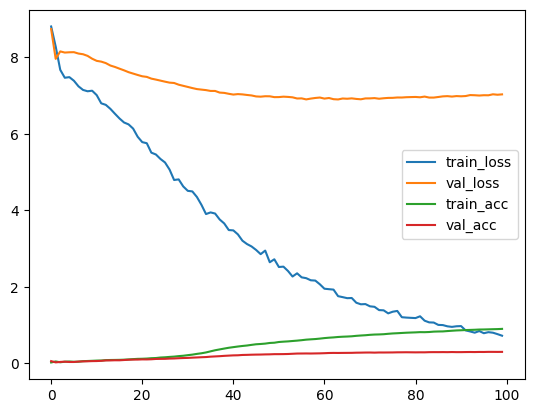

In [ ]:
#그래프 그리기
import matplotlib.pyplot as plt

pd.DataFrame({
    'train_loss': train_losses,
    'val_loss':   val_losses,
    'train_acc':  train_accs,
    'val_acc':    val_accs,
}).plot()
plt.show()

In [ ]:
#모델 저장
torch.save(model, 'seq2seq_chatbot.pth')

---

## 모델 로드

In [ ]:
#모델 로드
model = torch.load('seq2seq_chatbot.pth', weights_only=False)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(2250, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(6971, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=6971, bias=True)
  )
)

---

## 모델 추론 및 챗봇 생성

In [147]:
import numpy as np

In [149]:
# 6. 모델 추론
import numpy as np

def chatbot_answer(question, model, a_tokenizer, max_len=a_max_len, device=device):
    model = model.to(device)
    model.eval()
    encoder = model.encoder
    decoder = model.decoder

    # 질문을 토큰 시퀀스로 변환
    input_seq = q_tokenizer.texts_to_sequences([question])
    input_seq = pad_sequences(input_seq, maxlen=q_max_len, padding='pre')
    input_seq = torch.tensor(input_seq, dtype=torch.long).to(device)

    # Encoder 처리
    with torch.no_grad():
        hidden, cell = encoder(input_seq)

    # Decoder 출력 (Auto Regressive)
    sos_index = a_tokenizer.word_index['<sos>']
    eos_index = a_tokenizer.word_index['<eos>']

    output_words = []
    target_seq = torch.tensor([[sos_index]], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(max_len):
            output, hidden, cell = decoder(target_seq, hidden, cell)  # (batch_size, seq_len, vocab_size)
            proba = output.squeeze(1).softmax(dim=-1)                 # (batch_size, vocab_size)
            pred  = proba.argmax(dim=-1).detach().cpu().item()

            if pred == eos_index:
                break
            if pred > 0:
                word = a_tokenizer.index_word[pred]
                output_words.append(word)

            target_seq = torch.tensor([[pred]], dtype=torch.long).to(device)

    return ' '.join(output_words)

In [150]:
# 참고 파일처럼 랜덤 샘플 5개 추론
for _ in range(5):
    index     = np.random.choice(len(q_inputs))
    output    = chatbot_answer(q_inputs[index], model, a_tokenizer)

    print(f'질문: {q_inputs[index]}')
    print(f'정답: {a_inputs[index]}')
    print(f'모델 답변: {output}')
    print()

질문: Q101 맞춤형화장품판매장에 맞춤형화장품조제관리사를 두 명 이상 고용 하는 경우 모두 신고를 하여야 하나요?
정답: <sos>  맞춤형화장품판매장에 2명 이상의 조제관리사를 고용하는 경우에는 「화장품법 시행규칙」 제8조의2에 따른 맞춤형화장품판매업 신고 시 조제관리사를 추가 신고할 수 있으며, 신고된 조제관리사가 변경되는 경우 변경신고 대상에 해당됩니다.
모델 답변:  「화장품법」 제3조제3항 및 같은 법 시행규칙 제8조제2항에 따라 책임판매업자는 화장품을 수입할 때마다 「대외무역법」에 따른 수출·수입요령을 준수하여야 하며, 「전자무역 촉진에 관한 법률」에 따른 전자무역문서로 표준통관예정보고를 하여야 합니다. - 수입 시 벌크 화장품 법령에서 및 폐업에 관한 규정」 [별표2]에 등재되어 있지 않은 자외선차단제, 염모제 성분은 기능성화장품 심사를 받을 수 없으므로 원료 사용기준 심사 의뢰에 따라 목록에 등재 후 기능성화장품 심사가 가능함

질문: Q86 소비자가 맞춤형화장품을 사용한 후 부작용 발생을 알게 된 경우 맞춤형화장품판매업자가 부작용 보고를 해야 하나요?
정답: <sos>  맞춤형화장품판매업자가 맞춤형화장품 사용과 관련된 부작용 발생사례를 알게 된 경우에는 그 정보를 알게 된 날로부터 15일 이내에 식품의약품안전처장에게 보고하여야 합니다.(화장품 안전성 정보관리 규정 준용) ※ 보고방법 : 우리 처 의약품안전나라(http://nedrug.mfds.go.kr) 유해사례 보고란을 통하여 제출
모델 답변:  「화장품법」 제3조제3항 및 같은 법 시행규칙 제8조제2항에 따라 책임판매업자는 화장품을 수입할 때마다 「대외무역법」에 따른 수출·수입요령을 준수하여야 하며, 「전자무역 촉진에 관한 법률」에 따른 전자무역문서로 표준통관예정보고를 하여야 합니다. - 수입 시 벌크 화장품 법령에서 및 폐업에 관한 규정」 [별표2]에 등재되어 있지 않은 자외선차단제, 염모제 성분은 기능성화장품 심사를 받을 수 없으므로 원료 사용기준 심사 의뢰에 따라 목록에 등재

In [151]:
# 7. Chatbot 실행 (while문)
print("챗봇을 시작합니다. 종료하려면 'quit'을 입력하세요.")
print()

while True:
    user_input = input('사용자: ')

    if user_input.lower() == 'quit':
        print('챗봇을 종료합니다.')
        break

    answer = chatbot_answer(user_input, model, a_tokenizer)
    print(f'챗봇: {answer}')
    print()

챗봇을 시작합니다. 종료하려면 'quit'을 입력하세요.

챗봇:  「화장품법」 제5조제5항 및 같은 법 시행규칙 제13조에 따라 화장품책임판매업자는 화장품의 생산실적, 화장품의 제조 과정에서 사용된 원료의 목록 등을 식품의약품안전 처장에게 보고하여야 하며, 원료의 목록에 관한 보고는 화장품의 유통·판매 전까지 보고해야 합니다. - 「화장품의 생산·수입실적 및 원료목록 보고에 관한 규정」 [별표1]에 따라 생산실적 및 국내 제조 화장품의 원료목록은 (사)대한화장품협회에 보고하여야하므로, 생산실적 및 국내 제조 화장품의 원료목록 보고에 관한 세부적인 내용은 (사)대한화장품협회 (02-761-4205)로 문의하여 주시기 바랍니다.

챗봇:  「화장품법」 제3조제3항 및 같은 법 시행규칙 제8조제2항에 따라 책임판매업자는 화장품을 수입할 때마다 「대외무역법」에 따른 수출·수입요령을 준수하여야 하며, 「전자무역 촉진에 관한 법률」에 따른 전자무역문서로 표준통관예정보고를 하여야 합니다. - 수입 시 벌크 화장품 법령에서 및 폐업에 관한 규정」 [별표2]에 등재되어 있지 않은 자외선차단제, 염모제 성분은 기능성화장품 심사를 받을 수 없으므로 원료 사용기준 심사 의뢰에 따라 목록에 등재 후 기능성화장품 심사가 가능함

챗봇:  「화장품법」 제5조 및 같은 법 시행규칙 제13조에 따라 화장품책임판매업자는 화장품의 생산실적, 화장품의 제조 과정에서 사용된 원료의 목록 등을 식품의약품안전 처장에게 보고하여야 하며, 원료의 목록에 관한 보고는 화장품의 유통·판매 전까지 보고해야 합니다. - 다만, 및 관리자 등록과 관련하여 구체적인 사항은「화장품법 관한 규정」 제2조 및 제3조에 따라 생산실적 및 국내 제조 화장품의 원료목록은 (사)대한화장품협회에 보고하여야하므로, 생산실적 및 국내 제조 화장품의 원료목록은 (사)대한화장품협회에 보고하여야하므로, 생산실적 및 국내 제조 화장품의 원료목록 보고에 관한 세부적인 내용은 (사)대한화장품협회 (02-761-4205)로 문의하여 주시